In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Connect to your SQLite DB
engine = create_engine("sqlite:///bitcoin_data.db")

# Read data
df = pd.read_sql("SELECT * FROM bitcoin_prices", con=engine)

# Parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df.head()


,id,price
timestamp,,
2025-05-01 23:43:47.915534,1,96316.0
2025-05-02 00:17:17.427611,2,96607.0
2025-05-02 00:18:34.063963,3,96641.0
2025-05-02 00:23:17.716247,4,96631.0
2025-05-02 00:32:18.887062,5,96783.0


In [4]:
print(f"Total Records: {len(df)}")
print("Missing values:\n", df.isnull().sum())
print("Date Range:", df.index.min(), "to", df.index.max())

Total Records: 5
Missing values:
 id       0
price    0
dtype: int64
Date Range: 2025-05-01 23:43:47.915534 to 2025-05-02 00:32:18.887062


In [5]:
df['rolling_avg'] = df['price'].rolling(window=5).mean()

In [6]:
# Daily % change
df['returns'] = df['price'].pct_change()

# Volatility = standard deviation of returns
df['volatility'] = df['returns'].rolling(window=5).std()

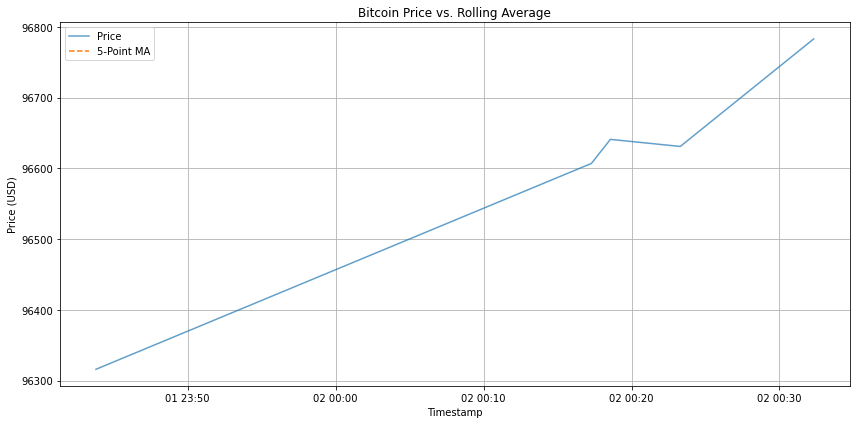

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['price'], label='Price', alpha=0.7)
plt.plot(df.index, df['rolling_avg'], label='5-Point MA', linestyle='--')
plt.title("Bitcoin Price vs. Rolling Average")
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

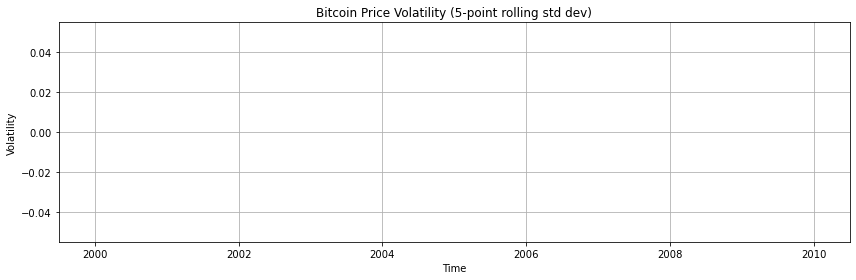

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['volatility'], color='red')
plt.title("Bitcoin Price Volatility (5-point rolling std dev)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.grid(True)
plt.tight_layout()
plt.show()